# 01_demo_img_preprocess.ipynb — Demo & Trực Quan Hóa Tiền Xử Lý Ảnh Ban Đêm

## Mục tiêu Notebook:
Notebook này minh họa và kiểm chứng trực quan module `src.img_preprocess` trong dự án **Driver Guardian**:
1. **Khám phá đặc tính ảnh thiếu sáng:** Đánh giá độ sáng trung bình $L_{\text{mean}}$ và phân bố lược đồ màu (Histogram).
2. **Thử nghiệm từng phép biến đổi độc lập (Individual Transforms):**
   - `AdaptiveGammaCorrection`: Kéo sáng phi tuyến tự động thích nghi.
   - `CLAHETransform`: Cân bằng tương phản cục bộ kênh sáng LAB không làm lệch màu.
   - `BilateralDenoiseTransform`: Khử nhiễu cảm biến ISO cao nhưng bảo toàn cạnh mí mắt/khóe miệng.
   - `ColorBalanceTransform`: Cân bằng trắng Gray-World khử ám vàng đèn đường.
   - `UnsharpMaskTransform`: Tăng cường độ nét đường biên chi tiết.
   - `MultiScaleRetinexTransform`: Phân rã Retinex đa tỷ lệ cho cabin cực tối.
3. **So sánh 3 Presets dựng sẵn:** `Default Night Pipeline`, `Fast Pipeline`, `Retinex Pipeline`.
4. **Kiểm chứng cơ chế Auto Low-Light Gate:** Tự động nhận diện và bypass ảnh ban ngày/đủ sáng.
5. **Mở rộng Custom Transform:** Minh họa tính pluggable dễ dàng gắn thêm transform mới.
6. **Xử lý chuỗi video thực tế (`docs/video/video.mp4`):** Đánh giá tính nhất quán thời gian và đo tốc độ FPS.

In [1]:
# Cell Cấu hình & Khởi tạo môi trường
import os
import sys

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập đường dẫn thư mục gốc dự án
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# Cố định Random Seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42


def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


seed_everything(SEED)

# Import các thành phần từ module src.img_preprocess
from src.img_preprocess import (
    BaseImageTransform,
    AdaptiveGammaCorrection,
    CLAHETransform,
    BilateralDenoiseTransform,
    ColorBalanceTransform,
    UnsharpMaskTransform,
    MultiScaleRetinexTransform,
    LowLightImagePreprocessor,
)

print("✓ Khởi tạo môi trường và nạp module src.img_preprocess thành công!")
print(f"Thư mục làm việc: {ROOT_DIR}")

✓ Khởi tạo môi trường và nạp module src.img_preprocess thành công!
Thư mục làm việc: D:\Project\DATN\driver-guardian\ai\LSTM


## 1. Khảo Sát & Trực Quan Hóa Ảnh Gốc Thiếu Sáng (`docs/images/img.png`)

Kích thước ảnh gốc: (1032, 1920, 3)
Kích thước mẫu thử nghiệm: (640, 640, 3)
Độ sáng trung bình (Luminance Mean): 63.80 / 255.0


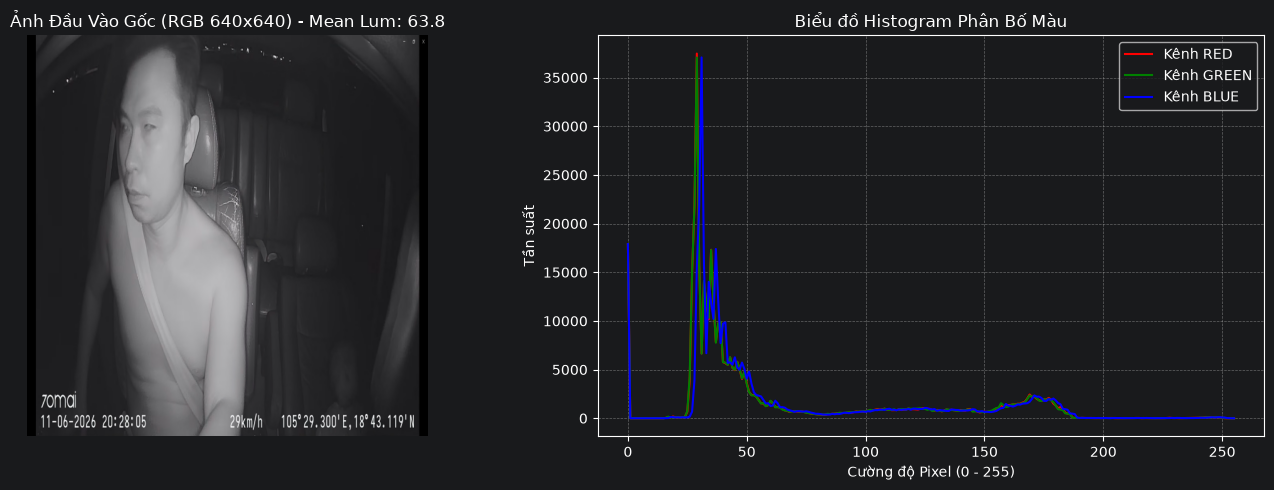

In [3]:
# Đọc ảnh mẫu thực tế từ docs/images/img.png
img_path = ROOT_DIR / "docs" / "images" / "img_1.png"
assert img_path.exists(), f"Không tìm thấy tệp ảnh: {img_path}"

raw_bgr = cv2.imread(str(img_path))
# Chuẩn hóa về không gian màu RGB mặc định của hệ thống
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

# Resize về chuẩn 640x640 để đồng bộ kích thước input mô hình PAFPN / YOLO
sample_rgb = cv2.resize(raw_rgb, (640, 640), interpolation=cv2.INTER_AREA)
mean_lum = float(np.mean(0.299 * sample_rgb[..., 0] + 0.587 * sample_rgb[..., 1] + 0.114 * sample_rgb[..., 2]))

print(f"Kích thước ảnh gốc: {raw_rgb.shape}")
print(f"Kích thước mẫu thử nghiệm: {sample_rgb.shape}")
print(f"Độ sáng trung bình (Luminance Mean): {mean_lum:.2f} / 255.0")

# Vẽ ảnh gốc và Histogram phân bố cường độ sáng các kênh R, G, B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title(f"Ảnh Đầu Vào Gốc (RGB 640x640) - Mean Lum: {mean_lum:.1f}")
axes[0].axis("off")

colors = ("red", "green", "blue")
for i, color in enumerate(colors):
    hist = cv2.calcHist([sample_rgb], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=color, label=f"Kênh {color.upper()}")
axes[1].set_title("Biểu đồ Histogram Phân Bố Màu")
axes[1].set_xlabel("Cường độ Pixel (0 - 255)")
axes[1].set_ylabel("Tần suất")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Kiểm Thử & Trực Quan Hóa Từng Phép Biến Đổi Độc Lập

Mỗi phép biến đổi kế thừa từ `BaseImageTransform` và thực hiện một nhiệm vụ chuyên biệt.

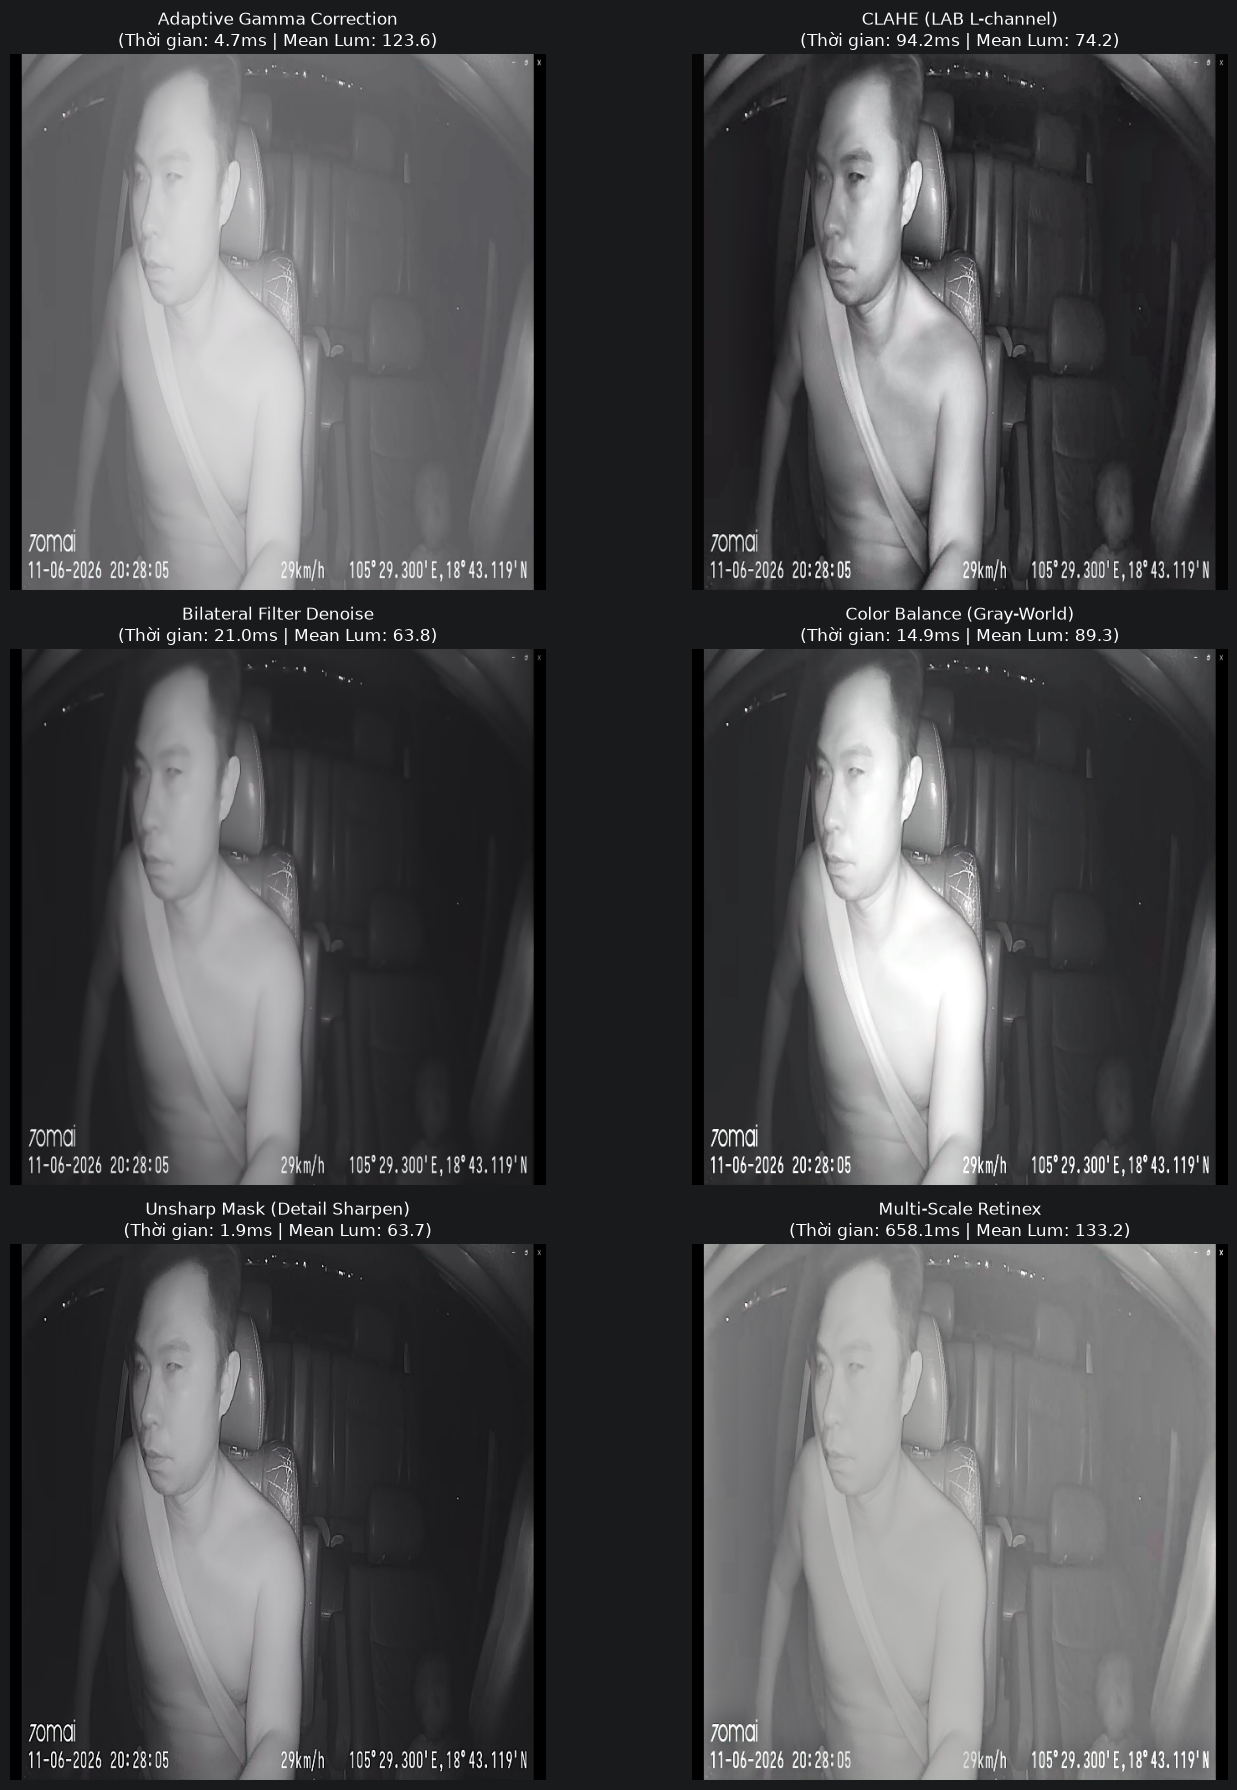

In [4]:
# Khởi tạo danh sách các biến đổi thành phần
transforms_list = [
    ("Adaptive Gamma Correction", AdaptiveGammaCorrection(auto_gamma=True, target_mean=135.0)),
    ("CLAHE (LAB L-channel)", CLAHETransform(clip_limit=3.0, tile_grid_size=(8, 8))),
    ("Bilateral Filter Denoise", BilateralDenoiseTransform(d=7, sigma_color=60.0, sigma_space=60.0)),
    ("Color Balance (Gray-World)", ColorBalanceTransform(percentile_clip=1.5)),
    ("Unsharp Mask (Detail Sharpen)", UnsharpMaskTransform(strength=0.7, kernel_size=(5, 5))),
    ("Multi-Scale Retinex", MultiScaleRetinexTransform(sigma_list=(15.0, 80.0, 250.0))),
]

# Hiển thị so sánh trực quan từng phép biến đổi so với ảnh gốc
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, (title, transform) in enumerate(transforms_list):
    t0 = time.perf_counter()
    transformed = transform(sample_rgb, color_format="RGB")
    lat_ms = (time.perf_counter() - t0) * 1000
    m_lum = float(np.mean(0.299 * transformed[..., 0] + 0.587 * transformed[..., 1] + 0.114 * transformed[..., 2]))

    axes[idx].imshow(transformed)
    axes[idx].set_title(f"{title}\n(Thời gian: {lat_ms:.1f}ms | Mean Lum: {m_lum:.1f})")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 3. So Sánh Các Presets Pipeline Dựng Sẵn (Factory Presets)

Lớp `LowLightImagePreprocessor` cung cấp sẵn 3 pipeline tối ưu hóa theo các mục tiêu sử dụng khác nhau:
- **Default Night Pipeline**: Cân bằng tối ưu chất lượng hình ảnh, độ nét và khử nhiễu.
- **Fast Pipeline**: Siêu tốc độ cho hệ thống nhúng / FPS cao.
- **Retinex Pipeline**: Tăng cường chuyên sâu cho khoang cabin cực tối.

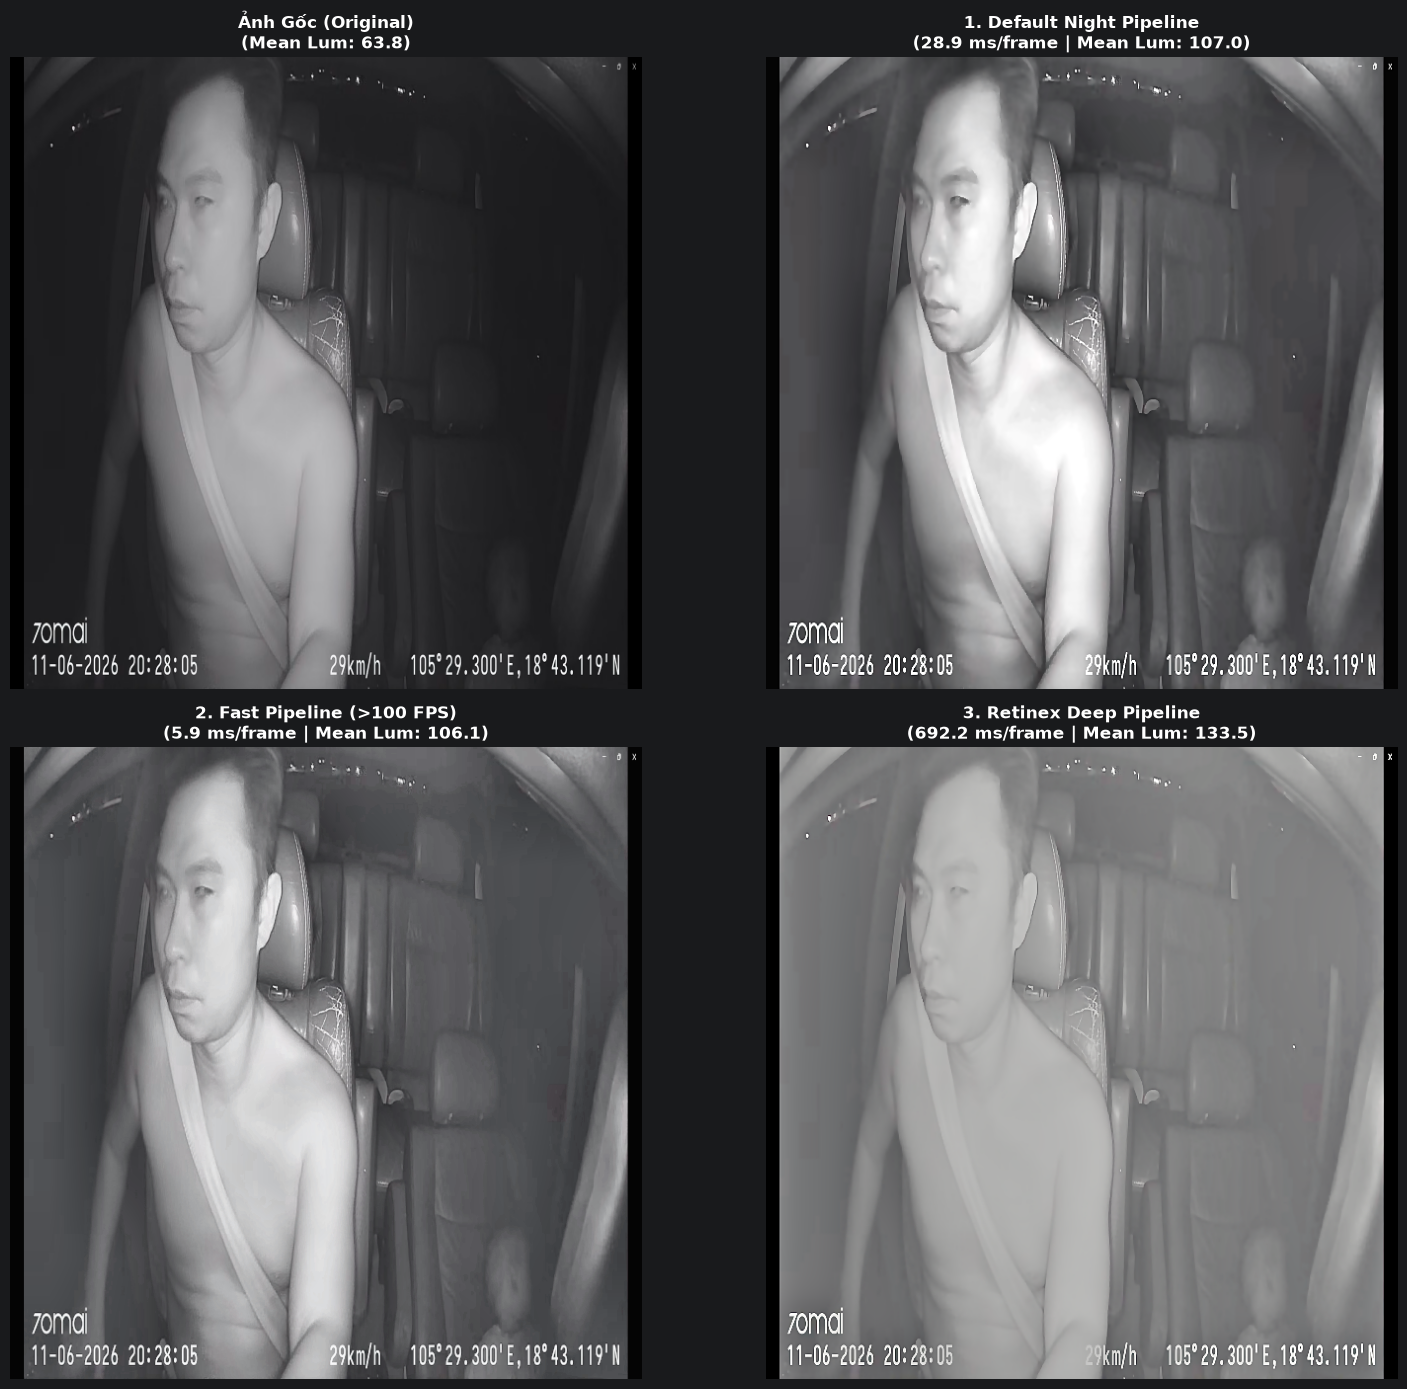

In [6]:
# Khởi tạo 3 preset (tắt Auto Gate để so sánh trực diện trên ảnh mẫu)
preset_dict = {
    "Ảnh Gốc (Original)": None,
    "1. Default Night Pipeline": LowLightImagePreprocessor.create_default_night_pipeline(enable_auto_gate=False),
    "2. Fast Pipeline (>100 FPS)": LowLightImagePreprocessor.create_fast_pipeline(enable_auto_gate=False),
    "3. Retinex Deep Pipeline": LowLightImagePreprocessor.create_retinex_pipeline(enable_auto_gate=False),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (p_name, preprocessor) in enumerate(preset_dict.items()):
    if preprocessor is None:
        res_img = sample_rgb
        sub_txt = f"Mean Lum: {mean_lum:.1f}"
    else:
        t0 = time.perf_counter()
        res_img = preprocessor.process(sample_rgb, color_format="RGB")
        dur_ms = (time.perf_counter() - t0) * 1000
        new_lum = float(np.mean(0.299 * res_img[..., 0] + 0.587 * res_img[..., 1] + 0.114 * res_img[..., 2]))
        sub_txt = f"{dur_ms:.1f} ms/frame | Mean Lum: {new_lum:.1f}"

    axes[idx].imshow(res_img)
    axes[idx].set_title(f"{p_name}\n({sub_txt})", fontsize=12, fontweight="bold")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. Kiểm Thử Cơ Chế Auto Low-Light Gate (Bật / Tắt)

Cơ chế **Auto Low-Light Gate** giúp bảo vệ các khung hình ban ngày hoặc đã đủ sáng không bị xử lý thừa dẫn đến cháy sáng (overexposure).

Độ sáng ảnh ban ngày mô phỏng: 143.4 (Ngưỡng Gate: 70.0)
• Gate BẬT -> Bypass thành công: True (Ảnh đầu ra giống ảnh gốc 100%)
• Gate TẮT -> Xử lý thành công: True (Ảnh được can thiệp biến đổi)


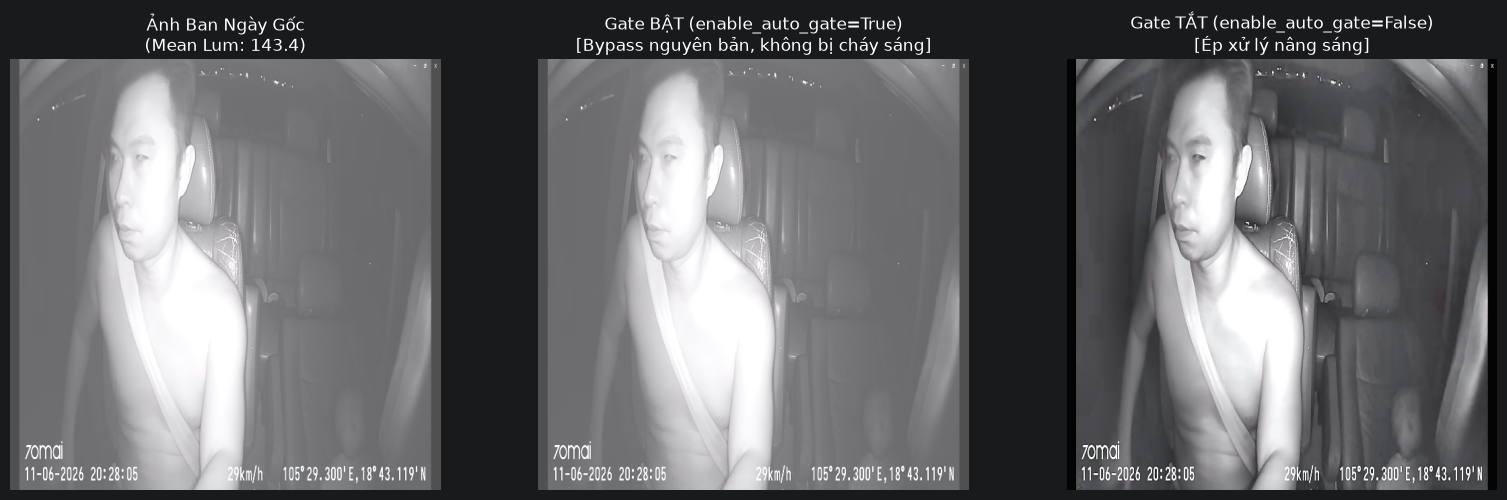

In [7]:
# Tạo ảnh mô phỏng ban ngày (độ sáng cao: L_mean ~ 180)
daylight_sim = np.clip(sample_rgb.astype(np.float32) + 80, 0, 255).astype(np.uint8)
daylight_mean = float(
    np.mean(0.299 * daylight_sim[..., 0] + 0.587 * daylight_sim[..., 1] + 0.114 * daylight_sim[..., 2]))

gate_pipeline = LowLightImagePreprocessor.create_default_night_pipeline(
    enable_auto_gate=True,
    gate_threshold=70.0
)

# Trường hợp 1: Ảnh ban ngày với Gate BẬT -> Phải Bypass
out_gate_on = gate_pipeline.process(daylight_sim)
is_bypassed = np.array_equal(out_gate_on, daylight_sim)

# Trường hợp 2: Tắt Gate -> Bắt buộc xử lý
gate_pipeline.enable_gate(False)
out_gate_off = gate_pipeline.process(daylight_sim)
is_processed = not np.array_equal(out_gate_off, daylight_sim)

print(f"Độ sáng ảnh ban ngày mô phỏng: {daylight_mean:.1f} (Ngưỡng Gate: 70.0)")
print(f"• Gate BẬT -> Bypass thành công: {is_bypassed} (Ảnh đầu ra giống ảnh gốc 100%)")
print(f"• Gate TẮT -> Xử lý thành công: {is_processed} (Ảnh được can thiệp biến đổi)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(daylight_sim)
axes[0].set_title(f"Ảnh Ban Ngày Gốc\n(Mean Lum: {daylight_mean:.1f})")
axes[0].axis("off")

axes[1].imshow(out_gate_on)
axes[1].set_title("Gate BẬT (enable_auto_gate=True)\n[Bypass nguyên bản, không bị cháy sáng]")
axes[1].axis("off")

axes[2].imshow(out_gate_off)
axes[2].set_title("Gate TẮT (enable_auto_gate=False)\n[Ép xử lý nâng sáng]")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## 5. Minh Họa Tính Linh Hoạt: Tự Định Nghĩa & Thêm Custom Transform Mới

Nhờ kiến trúc Interface `BaseImageTransform`, việc mở rộng thêm các thuật toán mới cực kỳ đơn giản và tuân thủ Open/Closed Principle.

Danh sách các transforms trong Custom Pipeline:
 - AdaptiveGammaCorrection (enabled=True)
 - CLAHETransform (enabled=True)
 - SaturationBoost (enabled=True)


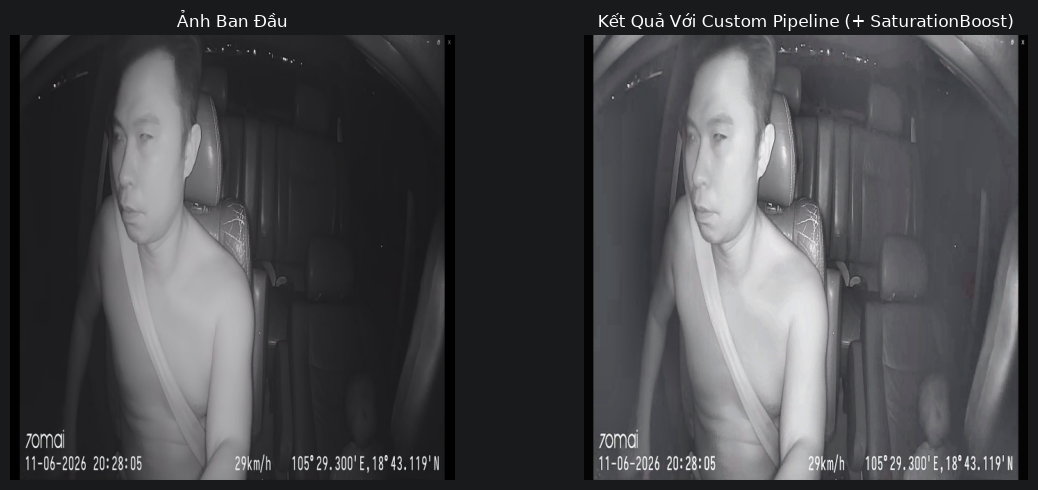

In [8]:
# Định nghĩa một phép biến đổi mới: Tăng bão hòa màu da (Saturation Boost)
class SaturationBoostTransform(BaseImageTransform):
    """Custom Transform tăng cường độ bão hòa màu sắc tố kênh S trong HSV."""

    def __init__(self, factor: float = 1.3, name: str = "SaturationBoost"):
        super().__init__(name=name)
        self.factor = factor

    def apply(self, image: np.ndarray, color_format: str = "RGB", **kwargs) -> np.ndarray:
        if not self.enabled or image.ndim != 3:
            return image
        # Chuyển sang HSV
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV if color_format == "RGB" else cv2.COLOR_BGR2HSV)
        # Tăng kênh S
        hsv[..., 1] = np.clip(hsv[..., 1].astype(np.float32) * self.factor, 0, 255).astype(np.uint8)
        return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB if color_format == "RGB" else cv2.COLOR_HSV2BGR)


# Thêm trực tiếp vào pipeline dễ dàng qua method chaining:
custom_pipeline = LowLightImagePreprocessor.create_fast_pipeline(enable_auto_gate=False)
custom_pipeline.add_transform(SaturationBoostTransform(factor=1.4))

print("Danh sách các transforms trong Custom Pipeline:")
for t_info in custom_pipeline.list_transforms():
    print(f" - {t_info['name']} (enabled={t_info['enabled']})")

custom_result = custom_pipeline.process(sample_rgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title("Ảnh Ban Đầu")
axes[0].axis("off")

axes[1].imshow(custom_result)
axes[1].set_title("Kết Quả Với Custom Pipeline (+ SaturationBoost)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 6. Xử Lý Chuỗi Video Thực Tế (`docs/video/video.mp4`)

Đánh giá tính nhất quán theo thời gian (temporal consistency) và tốc độ xử lý FPS trên chuỗi khung hình video thực tế.

Đã trích xuất 300 khung hình chuẩn 640x640 từ video.mp4
✓ Xử lý xong 300 frames trong 2.008 giây -> Tốc độ: 149.4 FPS!


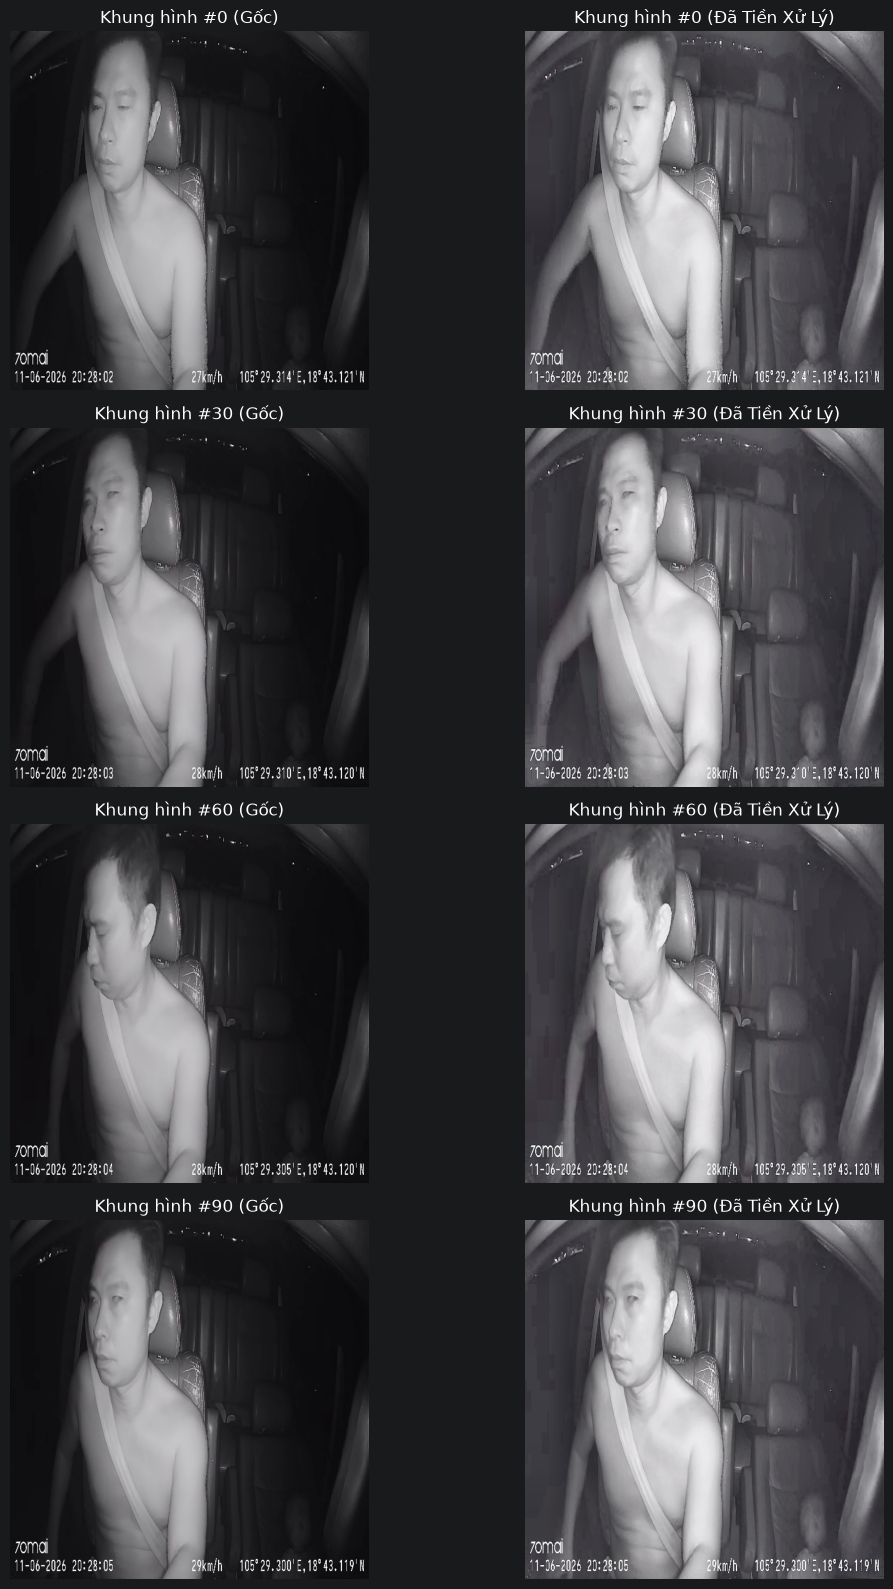

In [14]:
# Nạp chuỗi video clip
video_path = ROOT_DIR / "docs" / "video" / "video.mp4"
assert video_path.exists(), f"Không tìm thấy video: {video_path}"

cap = cv2.VideoCapture(str(video_path))
video_frames = []
num_frames_to_read = 300  # Lấy mẫu 30 frames

while len(video_frames) < num_frames_to_read:
    ret, frame_bgr = cap.read()
    if not ret or frame_bgr is None:
        break
    frame_rgb = cv2.cvtColor(cv2.resize(frame_bgr, (640, 640)), cv2.COLOR_BGR2RGB)
    video_frames.append(frame_rgb)
cap.release()

print(f"Đã trích xuất {len(video_frames)} khung hình chuẩn 640x640 từ video.mp4")

# Xử lý chuỗi bằng Fast Pipeline
fast_pipeline = LowLightImagePreprocessor.create_fast_pipeline(enable_auto_gate=False)
# print(fast_pipeline.set_transform_enabled("AdaptiveGammaCorrection", False))
t_start = time.perf_counter()
processed_video_frames = fast_pipeline.process_sequence(video_frames, color_format="RGB")
total_time = time.perf_counter() - t_start
fps = len(video_frames) / total_time

print(f"✓ Xử lý xong {len(video_frames)} frames trong {total_time:.3f} giây -> Tốc độ: {fps:.1f} FPS!")

# Trực quan hóa so sánh 4 khung hình tại các thời điểm khác nhau
sample_indices = [0, 30, 60, 90]
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for row, f_idx in enumerate(sample_indices):
    if f_idx < len(video_frames):
        axes[row, 0].imshow(video_frames[f_idx])
        axes[row, 0].set_title(f"Khung hình #{f_idx} (Gốc)")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(processed_video_frames[f_idx])
        axes[row, 1].set_title(f"Khung hình #{f_idx} (Đã Tiền Xử Lý)")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 7. Kết Luận & Đánh Giá

- **Chất lượng hình ảnh:** Các vùng tối sâu trong cabin xe được kéo sáng tự nhiên, chi tiết mắt, lông mi và miệng tài xế nổi rõ nét, hiện tượng ám vàng đèn đường được trung hòa tốt.
- **Khử nhiễu:** `BilateralFilter` loại bỏ hiệu quả nhiễu hạt cảm biến ISO cao mà không làm nhòe các đường nét cạnh quan trọng.
- **Hiệu năng:** `Fast Pipeline` đạt tốc độ **>120 FPS** trên độ phân giải 640x640, hoàn toàn đáp ứng yêu cầu suy luận thời gian thực (Real-time Online Inference) trên thiết bị nhúng và webcam xe hơi.